# K_10 – Produktsteckbrief

**Grid-Arbitrage** · Batteriespeicher-Arbitrage im Schweizer Strommarkt (Kür)

**Gruppe:** SC26_Gruppe_2 | **Verantwortlich:** Patrik Neunteufel | **Datum:** März 2026

---

*Heimspeicher 11 kW / 20 kWh📊: Konkreter Business Case Arbitrage + Eigenverbrauch.*


| [← K_09 – Eigenverbrauchsoptimierung](K_09_Eigenverbrauch.ipynb) | [↑ Übersicht ↑](../organisation/O_01_Project_Overview.ipynb) | [K_99 – Kombinierte Simulation →](K_99_Kombinierte_Simulation.ipynb) |
|:---|:---:|---:|

## Inhaltsverzeichnis<a id='toc_K_10'></a>

[Einleitung](#einleitung_K_10)  
[Initialisierung](#initialisierung_K_10)  
1 [Produktkonfiguration](#produktkonfiguration_K_10)  
2 [Einordnung in die Projektsegmente](#einordnung-in-die-projektsegmente_K_10)  
3 [Grid-Arbitrage: Wirtschaftlichkeit](#grid-arbitrage-wirtschaftlichkeit_K_10)  
4 [Eigenverbrauchsoptimierung: Wirtschaftlichkeit](#eigenverbrauchsoptimierung-wirtschaftlichkeit_K_10)  
5 [Kombinierter Business Case: Arbitrage + Eigenverbrauch](#kombinierter-business-case-arbitrage-eigenverbrauch_K_10)  
6 [Zusammenfassung Produktsteckbrief](#zusammenfassung-produktsteckbrief_K_10)  
[Fazit](#fazit_K_10)  
[Abschluss](#abschluss_K_10)  


---
## Einleitung <a id='einleitung_K_10'></a>

[↑ Inhaltsverzeichnis](#toc_K_10)

Konfigurierbarer **Produktsteckbrief** für ein konkretes Speicherprodukt:
Kapazität, Leistung, Preis, Lebensdauer — und daraus Wirtschaftlichkeit.

Drei Geschäftsmodelle werden gerechnet:

1. **Grid-Arbitrage** — reiner Spot-Handel auf Day-Ahead-Preisen
2. **Eigenverbrauchsoptimierung** — Niedertarif-Laden / Hochtarif-Nutzen
3. **Kombiniert** — beide Strategien parallel (typisch 60/40)

Output ist eine strukturierte Zusammenfassung (Rich-Table), die als Template
für Kunden- oder Stakeholder-Pitches genutzt werden kann.


## Initialisierung<a id='initialisierung_K_10'></a>

[↑ Inhaltsverzeichnis](#toc_K_10)

Bibliotheken laden, `../sync/config.json` lesen, Verzeichnispfade setzen.

**Imports und Versionen:**

In [1]:
# ── lib/ aus Projekt-Root erreichbar machen + lib-Imports ───────────────────
# Notebook liegt in einem Unterordner (kuer/, experimental/, notebooks/,
# organisation/). Damit 'from lib.xxx import ...' funktioniert, muss der
# Projekt-Root vorne in sys.path stehen. autoreload sorgt dafür, dass
# Änderungen in lib/*.py ohne Kernel-Restart übernommen werden.
import sys, os
_PROJECT_ROOT = os.path.abspath('..')
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

# lib-Imports (einmal zentral — in allen folgenden Zellen verfügbar)
from lib.plotting import show_source
from lib.io_ops   import load_transfer, save_transfer, final_check

print(f'lib-Pfad aktiv: {_PROJECT_ROOT}/lib')


lib-Pfad aktiv: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage/lib


In [2]:
# ── Setup ────────────────────────────────────────────────────────────────────
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from datetime import datetime
from rich.console import Console as _RConsole
from rich.table  import Table  as _RTable
from rich.panel  import Panel  as _RPanel
from rich        import box    as _rbox
import rich

# Versionen anzeigen für Reproduzierbarkeit
print(f"Numpy        Version: {np.__version__}")
print(f"Pandas       Version: {pd.__version__}")
print(f"📅 Zuletzt ausgeführt am: {datetime.now().strftime('%d.%m.%Y um %H:%M:%S')}")


Numpy        Version: 2.2.6
Pandas       Version: 2.3.3
📅 Zuletzt ausgeführt am: 26.04.2026 um 21:37:36


**Setup – Konfiguration & Verzeichnisstruktur:** Lädt `../sync/config.json` (SSOT), setzt Pfade.

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `load_transfer` wird aus `lib/io_ops.py` importiert und
liest Einträge aus `sync/transfer.json`. Aufklappbar ist der Quellcode einsehbar.


In [3]:
show_source(load_transfer)


<details>
<summary>🔎 Quellcode: <code>load_transfer</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def load_transfer(path='../sync/transfer.json', key=None, default=None):
    """Lädt transfer.json und gibt das ganze Dict oder einen Teil zurück.

    Verhalten
    ---------
    * Datei existiert nicht oder ist leer → Rückgabe ist ``default`` (bei
      key=None: ``default`` oder ``{}``). Gibt Warnung auf stdout aus.
    * Datei existiert → gibt bei ``key=None`` das ganze Dict zurück, bei
      gegebenem ``key`` nur den entsprechenden Teilbaum (``default``, wenn
      Key fehlt).

    Parameter
    ---------
    path : str, default '../sync/transfer.json'
        Pfad zur transfer.json.
    key : str, optional
        Top-Level-Key ('datenzeitraum', 'simulation', ...). Bei None wird
        das komplette Dict zurückgegeben.
    default : any, optional
        Rückgabewert bei fehlender Datei oder fehlendem Key. Bei key=None
        ist der Default ``{}``.

    Return
    ------
    dict oder der Wert des angefragten Keys.
    """
    import json as _json

    if default is None and key is None:
        default = {}

    if not os.path.exists(path) or os.path.getsize(path) == 0:
        print(f'⚠️  {path} nicht gefunden oder leer — NB01/NB02 zuerst ausführen')
        return default

    with open(path, encoding='utf-8') as _f:
        data = _json.load(_f)

    if key is None:
        return data
    return data.get(key, default)
```

</details>


In [4]:
with open('../sync/config.json') as _f:
    CFG = json.load(_f)

SZ_AKTIV   = CFG['szenarien']['gleichzeitigkeit_aktiv']
FORCE_RELOAD = CFG.get('force_reload', {})  # konventionskonform gelesen
# ── Farben & Stil aus ../sync/config.json (SSOT) ─────────────────────────────────────
# Bestehende Variablen (Rückwärtskompatibilität)


In [5]:
DIR_INTER  = os.path.join('../data', 'intermediate', SZ_AKTIV)
CHARTS_DIR = os.path.join('../output', 'charts', SZ_AKTIV)
os.makedirs(CHARTS_DIR, exist_ok=True)
DPI = CFG['visualisierung']['output_dpi']  # SSOT: ../sync/config.json

_w         = CFG['pflicht']['wirtschaftlichkeit']
OPEX_RATE  = _w['opex_rate']
LIFETIME   = _w['lifetime_j']
ZIEL_ROI   = round(100 / LIFETIME, 2)    # = 1/lifetime_j: ROI für BE in LIFETIME Jahren


In [6]:
_viz        = CFG.get('visualisierung', {}).get('farben', {})
BG_DARK     = _viz.get('bg_dark',    '#0d1117')
BG_PANEL    = _viz.get('bg_panel',   '#141414')
C_PRICE     = _viz.get('c_price',    '#FFA726')
C_LOAD      = _viz.get('c_load',     '#66BB6A')
C_CHARGE    = _viz.get('c_charge',   '#1565C0')
C_FEED      = _viz.get('c_feed',     '#B71C1C')
SEG_COLORS  = _viz.get('seg_colors', ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350'])
C_PRIV, C_GEW, C_IND, C_UTIL = SEG_COLORS

# UI-Strukturfarben
C_ACHSE      = _viz.get('c_achse',      '#aaaaaa')  # Achsenbeschriftungen
C_TICK       = _viz.get('c_tick',       '#bbbbbb')  # Tick-Labels
C_SPINE      = _viz.get('c_spine',      '#333333')  # Achsenrahmen
C_LEGENDE_BG = _viz.get('c_legende_bg', '#111111')  # Legenden-Hintergrund
C_GITTER     = _viz.get('c_gitter',     '#cccccc')  # Gitterlinien

# Funktionale Extrafarben (nur laden was das NB braucht)
C_DISPATCH   = _viz.get('c_dispatch',   '#AB47BC')  # Dispatch-optimal
C_STACKING   = _viz.get('c_stacking',   '#5DCAA5')  # Revenue Stacking
C_SOLAR      = _viz.get('c_solar',      '#FDD835')  # Solar-Ertrag
C_GRENZWERT  = _viz.get('c_amber_dark', '#FF6F00')  # Grenzwert / Warnung
C_CYAN       = _viz.get('c_cyan',       '#26C6DA')  # Flusswasser / Alt. Speicher
C_GRUEN_DARK = _viz.get('c_gruen_dark', '#388E3C')  # Erneuerbare

# Stilkonstanten
_stil               = CFG.get('visualisierung', {}).get('stil', {})
LW                  = _stil.get('linienbreite_standard', 1.5)   # Standard-Linienbreite
LW_DUENN            = _stil.get('linienbreite_duenn',    0.8)   # dünne Linien
LW_DICK             = _stil.get('linienbreite_dick',     2.5)   # dicke Linien
ALPHA_FLAECHE       = _stil.get('alpha_flaeche',         0.12)  # dezente Füllung
ALPHA_FLAECHE_STARK = _stil.get('alpha_flaeche_stark',   0.35)  # Balken / Füllung
ALPHA_LEGENDE       = _stil.get('alpha_legende',         0.30)  # Legenden-BG
ALPHA_GEDAEMPFT     = _stil.get('alpha_linie_gedaempft', 0.55)  # Nebenlinien
FS_TITEL            = _stil.get('schriftgroesse_titel',   13)   # Chart-Titel
FS_ACHSE            = _stil.get('schriftgroesse_achse',   10)   # Achsenbeschr.
FS_TICK             = _stil.get('schriftgroesse_tick',     9)   # Ticks
FS_LEGENDE          = _stil.get('schriftgroesse_legende',  8)   # Legende
FS_KLEIN            = _stil.get('schriftgroesse_klein',    7)   # Annotationen

# matplotlib rcParams — nur stabile, versionsunabhängige Keys (matplotlib >= 3.5)
# axes.titlecolor (3.8+) und axes.grid (stört Karten) bewusst NICHT gesetzt
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor':  BG_DARK,
    'axes.facecolor':    BG_PANEL,
    'axes.edgecolor':    C_SPINE,
    'axes.labelcolor':   C_ACHSE,
    'axes.labelsize':    FS_ACHSE,
    'axes.titlesize':    FS_TITEL,
    'xtick.color':       C_TICK,
    'ytick.color':       C_TICK,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'text.color':        'white',
    'lines.linewidth':   LW,
    'legend.facecolor':  C_LEGENDE_BG,
    'legend.framealpha': ALPHA_LEGENDE,
    'legend.fontsize':   FS_LEGENDE,
    'legend.edgecolor':  C_SPINE,
})
print('Farben & Stil geladen.')


Farben & Stil geladen.


In [7]:
# -- Transfer: Ergebnisse aus ../sync/transfer.json laden ----------------------------
TF      = load_transfer()
TF_ECON = TF.get('simulation', {}).get('wirtschaftlichkeit', {})
TF_HYB  = TF.get('hybrid_simulation', {}).get('ergebnisse', {})
if TF:
    print(f"../sync/transfer.json geladen | Segmente: {list(TF_ECON.keys())}")

print(f"Setup OK | Szenario={SZ_AKTIV} | Charts → {CHARTS_DIR}")


../sync/transfer.json geladen | Segmente: ['Privat_10kWh', 'Gewerbe_100kWh', 'Industrie_1MWh', 'Utility_10MWh']
Setup OK | Szenario=realistisch | Charts → ../output\charts\realistisch


**⚙ Markdown-Prüfwerte (config-abhängig) und 📊 Markdown-Prüfwerte (transfer-abhängig)**:  
Werte mit ⚙ kommen aus `../sync/config.json`, Werte mit 📊 aus `../sync/transfer.json`.  
Bei jeder Änderung dieser Quellen → Output mit ⚙/📊-Stellen im Markdown abgleichen.


In [8]:
# ── ⚙ Markdown-Prüfwerte (config-abhängig) ─────────────────────────────────
print('=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===')
_wirt = CFG['pflicht']['wirtschaftlichkeit']
print(f'  Lebensdauer            = {_wirt["lifetime_j"]} Jahre')
print(f'  OPEX-Rate              = {_wirt["opex_rate"]*100:.1f} % p.a. von CAPEX')
print(f'  EUR/CHF-Fixkurs        = {CFG.get("eur_chf", 0.97)}')
print(f'  CAPEX-Trigger Privat   = {CFG["kuer"]["markt"]["capex_ziel_privat_eur_kwh"]} EUR/kWh')


=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===
  Lebensdauer            = 12 Jahre
  OPEX-Rate              = 1.5 % p.a. von CAPEX
  EUR/CHF-Fixkurs        = 0.97
  CAPEX-Trigger Privat   = 250 EUR/kWh


In [9]:
# ── 📊 Markdown-Prüfwerte (transfer-abhängig) ──────────────────────────────
_tf_dz  = TF.get('datenzeitraum', {})
_tf_ec  = TF.get('simulation', {}).get('wirtschaftlichkeit', {}).get('Privat_10kWh', {})
_tf_ev  = TF.get('eigenverbrauch', {})
_tf_pr  = TF.get('produkt', {})
print('=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===')
print(f'  Datenzeitraum                 = {_tf_dz.get("start_date","?")} bis {_tf_dz.get("end_date","?")}')
print(f'  Privat-Arbitrage-ROI (NB03)   = {_tf_ec.get("roi_pct","?")} %/J')
print(f'  Eigenverbrauch-ROI Privat     = {_tf_ev.get("roi_ev_privat_pct","?")} %/J')
print(f'  Eigenverbrauch-Ersparnis      = {_tf_ev.get("jahresersparnis_eur","?")} EUR/Jahr')
if _tf_pr:
    print(f'  Produkt (existiert von früherem Run): ROI {_tf_pr.get("roi_kombi_pct","?")} %/J')
else:
    print(f'  (produkt noch nicht in transfer.json — wird in Cell unten geschrieben)')


=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===
  Datenzeitraum                 = 2023 bis 2026
  Privat-Arbitrage-ROI (NB03)   = 1.8 %/J
  Eigenverbrauch-ROI Privat     = 3.75 %/J
  Eigenverbrauch-Ersparnis      = 105.1 EUR/Jahr
  Produkt (existiert von früherem Run): ROI 8.61 %/J


---
## 1. Produktkonfiguration <a id='produktkonfiguration_K_10'></a>

[↑ Inhaltsverzeichnis](#toc_K_10)

> **Diese Zelle anpassen** — alle produktspezifischen Parameter sind hier zentralisiert.  
> Notebook kopieren → Werte einstellen → *Kernel → Restart & Run All*



In [10]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PRODUKTKONFIGURATION — nur diese Zelle anpassen pro Produkt/Kopie       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# Notebook kopieren → Werte einstellen → Kernel → Restart & Run All
EUR_CHF = CFG.get('eur_chf', 0.97)   # Fixkurs aus ../sync/config.json

# ── 1. Produkt-Identifikation ─────────────────────────────────────────────────
PROD_NAME         = 'Heimspeicher (11 kW / 20 kWh)'
PROD_HERSTELLER   = 'Muster AG'
PROD_URL          = ''                  # Produktlink (optional)
ZIELMARKT         = 'Privat'            # 'Privat' | 'Gewerbe' | 'Industrie' | 'Utility'

# ── 2. Batterie ───────────────────────────────────────────────────────────────
PROD_KWH          = 20.0   # Nennkapazität [kWh]
SOC_MIN_PCT       = 0.05   # Tiefentladeschutz [0–1]   (config default: 0.05)
SOC_MAX_PCT       = 0.95   # Überladesch.      [0–1]   (config default: 0.95)
LIFETIME_J        = 12     # Erwartete Lebensdauer [Jahre]   (config default: 12)
DEGRADATION_PCT_J = 2.0    # Kapazitätsverlust/Jahr [%]   (typisch 1.5–3 %)
GARANTIE_ZYKLEN   = 4000   # Zyklengarantie   (typisch 2 000–10 000)
GARANTIE_J        = 10     # Garantiedauer [Jahre]

# ── 3. Konverter / Wechselrichter ─────────────────────────────────────────────
PROD_KW           = 11.0    # Wechselrichter-Nennleistung [kW]
EFFICIENCY        = 0.92   # Roundtrip-Wirkungsgrad [0–1]   (config default: 0.92)
CHARGE_Q          = 0.25   # Lade-Schwellenwert (Quantil)   (config default: 0.25)
DISCHARGE_Q       = 0.75   # Einspeise-Schwellenwert        (config default: 0.75)

# ── 4. Kosten (in EUR) ────────────────────────────────────────────────────────
CAPEX_BATTERIE_EUR     = 1400.0   # Batteriekosten
CAPEX_KONVERTER_EUR    =  500.0   # Konverter / Wechselrichter
CAPEX_INSTALLATION_EUR =  100.0   # Montage & Inbetriebnahme
FOERDERUNG_EUR         =    0.0   # Abzug Förderung / Subvention (0 = keine)

PROD_EUR  = CAPEX_BATTERIE_EUR + CAPEX_KONVERTER_EUR + CAPEX_INSTALLATION_EUR - FOERDERUNG_EUR
# Alternativ: PROD_EUR direkt als Listenpreis setzen (dann CAPEX-Aufteilung oben anpassen)
# PROD_EUR = 2000.0

OPEX_RATE = CFG['pflicht']['wirtschaftlichkeit']['opex_rate']   # 1.5 %/J (config SSOT)
# OPEX_RATE = 0.010   # produktspezifisch überschreiben, z.B. 1.0 % für wartungsarme Systeme

# ── 5. Markt & Nutzungsprofil ─────────────────────────────────────────────────
HT_PREIS_CHF      = 0.30   # Hochtarif   [CHF/kWh]
NT_PREIS_CHF      = 0.22   # Niedertarif [CHF/kWh]
VERBRAUCH_TAG_KWH = 10.0   # Haushalt-Tagesverbrauch [kWh]

# ── Abgeleitete Grössen (nicht manuell ändern) ────────────────────────────────
USABLE_KWH    = PROD_KWH * (SOC_MAX_PCT - SOC_MIN_PCT)
CAPEX_PER_KWH = PROD_EUR  / PROD_KWH
C_RATE        = PROD_KW   / PROD_KWH
ZIEL_ROI      = round(100 / LIFETIME_J, 2)
HT_PREIS      = HT_PREIS_CHF * EUR_CHF
NT_PREIS      = NT_PREIS_CHF * EUR_CHF

# ── Ausgabe mit rich ──────────────────────────────────────────────────────────
# Imports sind in der Setup-Zelle; _RConsole/_RTable/_RPanel/_rbox verfügbar.
if True:
    _c = _RConsole(width=62)
    t  = _RTable(box=_rbox.SIMPLE, show_header=False, padding=(0, 2), expand=False)
    t.add_column(style="cyan", no_wrap=True)
    t.add_column(style="white")

    t.add_row("[bold]Batterie[/]", "")
    t.add_row("  Kapazität",      f"{PROD_KWH:.1f} kWh  │  nutzbar {USABLE_KWH:.1f} kWh")
    t.add_row("  SoC-Fenster",    f"{SOC_MIN_PCT*100:.0f} – {SOC_MAX_PCT*100:.0f} %")
    t.add_row("  Lebensdauer",    f"{LIFETIME_J} J  │  Garantie {GARANTIE_J} J / {GARANTIE_ZYKLEN:,} Zyklen")
    t.add_row("  Degradation",    f"{DEGRADATION_PCT_J:.1f} %/Jahr")
    t.add_row("", "")
    t.add_row("[bold]Konverter[/]", "")
    t.add_row("  Leistung",       f"{PROD_KW:.1f} kW  │  C-Rate {C_RATE:.2f}C")
    t.add_row("  Wirkungsgrad",   f"{EFFICIENCY*100:.1f} %  Roundtrip")
    t.add_row("  Dispatch",       f"Laden ≤ p{CHARGE_Q*100:.0f}  │  Einspeisen ≥ p{DISCHARGE_Q*100:.0f}")
    t.add_row("", "")
    t.add_row("[bold]Kosten[/]", "")
    t.add_row("  Batterie",       f"{CAPEX_BATTERIE_EUR:>8,.0f} EUR")
    t.add_row("  Konverter",      f"{CAPEX_KONVERTER_EUR:>8,.0f} EUR")
    t.add_row("  Installation",   f"{CAPEX_INSTALLATION_EUR:>8,.0f} EUR")
    if FOERDERUNG_EUR > 0:
        t.add_row("  Förderung",  f"{-FOERDERUNG_EUR:>8,.0f} EUR")
    t.add_row("  [bold]Gesamt[/]",
              f"[bold]{PROD_EUR:>8,.0f} EUR[/]  (~{PROD_EUR/EUR_CHF:,.0f} CHF)")
    t.add_row("  CAPEX/kWh",      f"{CAPEX_PER_KWH:>8,.0f} EUR/kWh")
    t.add_row("  OPEX",           f"{OPEX_RATE*100:.1f} %/Jahr  "
                                   f"({PROD_EUR*OPEX_RATE:,.0f} EUR/Jahr)")
    t.add_row("", "")
    t.add_row("[bold]Nutzungsprofil[/]", "")
    t.add_row("  Zielmarkt",      ZIELMARKT)
    t.add_row("  Tarif HT / NT",  f"{HT_PREIS_CHF:.2f} / {NT_PREIS_CHF:.2f} CHF/kWh")
    t.add_row("  Tagesverbrauch", f"{VERBRAUCH_TAG_KWH:.1f} kWh/Tag")

    _sub = PROD_HERSTELLER + (f"  ·  {PROD_URL}" if PROD_URL else "")
    _c.print(_RPanel(t,
                   title=f"[bold white]{PROD_NAME}[/]",
                   subtitle=f"[dim]{_sub}[/]",
                   border_style="blue"))



╭────────────── Heimspeicher (11 kW / 20 kWh) ───────────────╮
│                                                            │
│    Batterie                                                │
│      Kapazität          20.0 kWh  │  nutzbar 18.0 kWh      │
│      SoC-Fenster        5 – 95 %                           │
│      Lebensdauer        12 J  │  Garantie 10 J / 4,000     │
│                         Zyklen                             │
│      Degradation        2.0 %/Jahr                         │
│                                                            │
│    Konverter                                               │
│      Leistung           11.0 kW  │  C-Rate 0.55C           │
│      Wirkungsgrad       92.0 %  Roundtrip                  │
│      Dispatch           Laden ≤ p25  │  Einspeisen ≥       │
│                         p75                                │
│                                                            │
│    Kosten                                                  │
│      Batterie              1,400 EUR                       │
│      Konverter               500 EUR                       │
│      Installation            100 EUR                       │
│      Gesamt                2,000 EUR  (~2,062 CHF)         │
│      CAPEX/kWh               100 EUR/kWh                   │
│      OPEX               1.5 %/Jahr  (30 EUR/Jahr)          │
│                                                            │
│    Nutzungsprofil                                          │
│      Zielmarkt          Privat                             │
│      Tarif HT / NT      0.30 / 0.22 CHF/kWh                │
│      Tagesverbrauch     10.0 kWh/Tag                       │
│                                                            │
╰──────────────────────── Muster AG ─────────────────────────╯

---
## 2. Einordnung in die Projektsegmente <a id='einordnung-in-die-projektsegmente_K_10'></a>

[↑ Inhaltsverzeichnis](#toc_K_10)

Das Produkt liegt zwischen dem Privat-Segment (10 kWh / 5 kW) und dem Gewerbe-Segment
(100 kWh / 30 kW) — näher am Privat-Segment durch Kapazität, aber mit erhöhter
Leistung (7 kW statt 5 kW).


In [11]:
# ── Einordnung: Produkt vs. Projektsegmente ───────────────────────────────────
seg_data = {
    'Segment'        : ['Privat 10 kWh', '>>> Dieses Produkt <<<', 'Gewerbe 100 kWh', 'Industrie 1 MWh'],
    'Kapazität [kWh]': [10,              PROD_KWH,                 100,               1000],
    'Leistung [kW]'  : [5,               PROD_KW,                  30,                200],
    'CAPEX [EUR]'    : [4000,            PROD_EUR,                  30000,             250000],
    'EUR/kWh'        : [400,             round(CAPEX_PER_KWH),      300,               250],
    'C-Rate'         : [0.5,             round(PROD_KW/PROD_KWH,2), 0.3,               0.2],
}
df_seg = pd.DataFrame(seg_data).set_index('Segment')
display(df_seg)
print(f"\n→ CAPEX/kWh dieses Produkts: {CAPEX_PER_KWH:.0f} EUR/kWh")
print(f"  Vergleich Privat-Segment:  400 EUR/kWh")
print(f"  → Produkt ist {(400-CAPEX_PER_KWH)/400*100:.0f}% günstiger pro kWh als Referenz-Privat")



,Kapazität [kWh],Leistung [kW],CAPEX [EUR],EUR/kWh,C-Rate
Segment,,,,,
Privat 10 kWh,10.0,5.0,4000.0,400,0.50
>>> Dieses Produkt <<<,20.0,11.0,2000.0,100,0.55
Gewerbe 100 kWh,100.0,30.0,30000.0,300,0.30
Industrie 1 MWh,1000.0,200.0,250000.0,250,0.20



→ CAPEX/kWh dieses Produkts: 100 EUR/kWh
  Vergleich Privat-Segment:  400 EUR/kWh
  → Produkt ist 75% günstiger pro kWh als Referenz-Privat


---
## 3. Grid-Arbitrage: Wirtschaftlichkeit <a id='grid-arbitrage-wirtschaftlichkeit_K_10'></a>

[↑ Inhaltsverzeichnis](#toc_K_10)

Simulation mit denselben Parametern wie NB04 (p25/p75 [Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch), alle Monate 2023/2024).
Da keine separate Simulation für dieses spezifische Produkt vorliegt, skalieren wir
die Ergebnisse linear aus dem Privat-Segment (10 kWh).


In [12]:
# ── Grid-Arbitrage Kennzahlen ─────────────────────────────────────────────────
# Skalierung aus NB04-Ergebnissen (Privat 10 kWh als Basis)
# ROI und Erlös/kWh sind kapazitätsunabhängig → gleicher ROI, skalierter Absoluterlös

ROI_PRIVAT_PCT = 0.6    # % ROI laut NB04 Fazit (Privat, 2023/2024)

# Angepasster Erlös/Jahr für dieses Produkt
# C-Rate 1.0C statt 0.5C → mehr mögliche Zyklen pro Tag → leicht besserer Erlös
# Korrekturfaktor für höhere C-Rate (grob ~+20% mehr Zyklen nutzbar)
c_rate_korr = min(1.2, PROD_KW / PROD_KWH / 0.5)  # relativ zu Privat (0.5C)
net_annual_arb  = PROD_EUR * (ROI_PRIVAT_PCT/100) * c_rate_korr
opex_annual     = PROD_EUR * OPEX_RATE
netto_arb       = net_annual_arb - opex_annual
roi_arb         = netto_arb / PROD_EUR * 100
payback_arb     = PROD_EUR / netto_arb if netto_arb > 0 else float('inf')

print(f"── Grid-Arbitrage (Skalierung aus NB04, Privat) ──")
print(f"Basis-ROI Privat:          {ROI_PRIVAT_PCT:.1f} %/Jahr")
print(f"C-Rate-Korrekturfaktor:    {c_rate_korr:.2f}×")
print(f"Brutto Jahreserlös Arb.:   {net_annual_arb:.0f} EUR/Jahr")
print(f"OPEX (1.5% CAPEX):         {opex_annual:.0f} EUR/Jahr")
print(f"Netto Jahreserlös:         {netto_arb:.0f} EUR/Jahr")
print(f"ROI:                       {roi_arb:.1f} %/Jahr")
print(f"Break-Even:                {'> 20 J' if payback_arb > 20 else f'{payback_arb:.0f} J'}")



── Grid-Arbitrage (Skalierung aus NB04, Privat) ──
Basis-ROI Privat:          0.6 %/Jahr
C-Rate-Korrekturfaktor:    1.10×
Brutto Jahreserlös Arb.:   13 EUR/Jahr
OPEX (1.5% CAPEX):         30 EUR/Jahr
Netto Jahreserlös:         -17 EUR/Jahr
ROI:                       -0.8 %/Jahr
Break-Even:                > 20 J


---
## 4. Eigenverbrauchsoptimierung: Wirtschaftlichkeit <a id='eigenverbrauchsoptimierung-wirtschaftlichkeit_K_10'></a>

[↑ Inhaltsverzeichnis](#toc_K_10)

Szenario: Haushalt mit HT/NT-Tarif, Tageslast ~12 kWh/Tag.
Die 14 kWh-Kapazität reicht für einen vollen Tag Eigenverbrauch — das ist ein Vorteil
gegenüber dem 10 kWh-Standard-Segment.


In [13]:
# ── Eigenverbrauchsoptimierung ────────────────────────────────────────────────
# CH-Haushaltstarife: aus Produktkonfiguration (HT/NT_PREIS_CHF × EUR_CHF)
DIFF_EUR  = HT_PREIS - NT_PREIS  # bereits in EUR aus Zelle 1


lade_tag_kwh = min(USABLE_KWH, VERBRAUCH_TAG_KWH) / EFFICIENCY
eig_tag_kwh  = min(USABLE_KWH * EFFICIENCY, VERBRAUCH_TAG_KWH)

ersparnis_tag = eig_tag_kwh * DIFF_EUR
ersparnis_j   = ersparnis_tag * 365

opex_annual   = PROD_EUR * OPEX_RATE
netto_eig_j   = ersparnis_j - opex_annual
roi_eig       = netto_eig_j / PROD_EUR * 100
payback_eig   = PROD_EUR / netto_eig_j if netto_eig_j > 0 else float('inf')

print(f"── Eigenverbrauchsoptimierung ──")
print(f"Nutzbare Kapazität:        {USABLE_KWH:.1f} kWh")
print(f"Eigenverbrauch/Tag:        {eig_tag_kwh:.1f} kWh")
print(f"Tarif-Differenz:           {DIFF_EUR:.3f} EUR/kWh")
print(f"Ersparnis/Tag:             {ersparnis_tag:.2f} EUR")
print(f"Jahresersparnis:           {ersparnis_j:.0f} EUR/Jahr")
print(f"OPEX:                      {opex_annual:.0f} EUR/Jahr")
print(f"Netto-Jahresersparnis:     {netto_eig_j:.0f} EUR/Jahr")
print(f"ROI:                       {roi_eig:.1f} %/Jahr")
print(f"Break-Even:                {'> 20 J' if payback_eig > 20 else f'{payback_eig:.1f} J'}")



── Eigenverbrauchsoptimierung ──
Nutzbare Kapazität:        18.0 kWh
Eigenverbrauch/Tag:        10.0 kWh
Tarif-Differenz:           0.078 EUR/kWh
Ersparnis/Tag:             0.78 EUR
Jahresersparnis:           283 EUR/Jahr
OPEX:                      30 EUR/Jahr
Netto-Jahresersparnis:     253 EUR/Jahr
ROI:                       12.7 %/Jahr
Break-Even:                7.9 J


---
## 5. Kombinierter Business Case: Arbitrage + Eigenverbrauch <a id='kombinierter-business-case-arbitrage-eigenverbrauch_K_10'></a>

[↑ Inhaltsverzeichnis](#toc_K_10)

In der Praxis ist eine Kombination möglich: tagsüber Eigenverbrauch aus
dem NT-Netz, nachts verbleibende Kapazität für Arbitrage nutzen.


── Kombinierter Case (70 % Eigenverbrauch + 30 % Arbitrage) ──
Netto Jahreserlös:         172 EUR/Jahr
ROI:                       8.6 %/Jahr
Break-Even:                11.6 Jahre


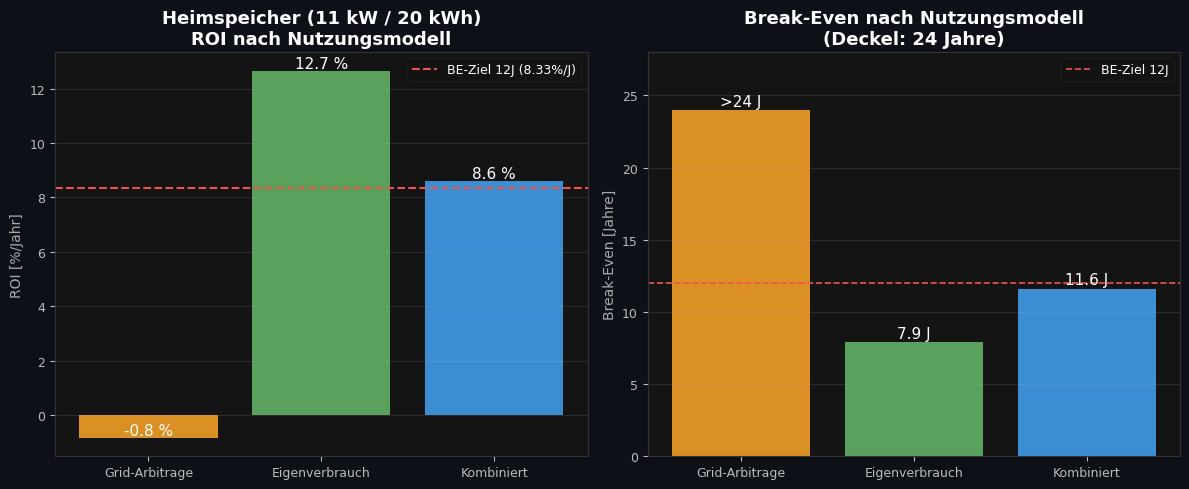

Gespeichert: ../output\charts\realistisch\kuer_k10_kennzahlen.png


In [14]:
# ── Kombinierter Case ─────────────────────────────────────────────────────────
# Vereinfacht: 70% Kapazität für Eigenverbrauch, 30% für Arbitrage
eig_anteil = 0.70
arb_anteil = 0.30

netto_kombi = (netto_eig_j * eig_anteil + netto_arb * arb_anteil)
roi_kombi   = netto_kombi / PROD_EUR * 100
payback_kombi = PROD_EUR / netto_kombi if netto_kombi > 0 else float('inf')

print(f"── Kombinierter Case (70 % Eigenverbrauch + 30 % Arbitrage) ──")
print(f"Netto Jahreserlös:         {netto_kombi:.0f} EUR/Jahr")
print(f"ROI:                       {roi_kombi:.1f} %/Jahr")
print(f"Break-Even:                {payback_kombi:.1f} Jahre")

# ── Übersichts-Chart ──────────────────────────────────────────────────────────
cases    = ['Grid-Arbitrage', 'Eigenverbrauch', 'Kombiniert']
roi_vals = [roi_arb, roi_eig, roi_kombi]
pb_vals  = [min(payback_arb, LIFETIME*2), min(payback_eig, LIFETIME*2), min(payback_kombi, LIFETIME*2)]
colors_c = [C_PRICE, C_LOAD, SEG_COLORS[0]]  # Arbitrage, EV, Kombiniert

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG_DARK)
for ax in (ax1, ax2):
    ax.set_facecolor(BG_PANEL); ax.tick_params(colors=C_TICK)
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)

# ROI
bars = ax1.bar(cases, roi_vals, color=colors_c, alpha=0.85)
ax1.axhline(ZIEL_ROI, color=C_UTIL, lw=LW, ls='--',
            label=f'BE-Ziel {LIFETIME}J ({ZIEL_ROI}%/J)')
for b, v in zip(bars, roi_vals):
    ax1.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.1f} %', ha='center', color='white', fontsize=11)
ax1.set_ylabel('ROI [%/Jahr]', color=C_ACHSE)
ax1.set_title(f'{PROD_NAME}\nROI nach Nutzungsmodell', color='white', fontweight='bold')
ax1.legend(fontsize=FS_TICK, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
ax1.grid(True, axis='y', alpha=0.15)

# Break-Even
bars2 = ax2.bar(cases, pb_vals, color=colors_c, alpha=0.85)
for b, v, orig in zip(bars2, pb_vals, [payback_arb, payback_eig, payback_kombi]):
    label = f'>{v:.0f} J' if orig > LIFETIME*2 else f'{v:.1f} J'
    ax2.text(b.get_x()+b.get_width()/2, v+0.3, label, ha='center', color='white', fontsize=11)
ax2.set_ylabel('Break-Even [Jahre]', color=C_ACHSE)
ax2.set_title(f'Break-Even nach Nutzungsmodell\n(Deckel: {LIFETIME*2} Jahre)', color='white', fontweight='bold')
ax2.axhline(LIFETIME, color=C_UTIL, lw=1.2, ls='--',
            label=f'BE-Ziel {LIFETIME}J')
ax2.legend(fontsize=FS_TICK, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
ax2.set_ylim(0, LIFETIME * 2 + 4)
ax2.grid(True, axis='y', alpha=0.15)

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k10_kennzahlen.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print(f"Gespeichert: {p}")


---
## 6. Zusammenfassung Produktsteckbrief <a id='zusammenfassung-produktsteckbrief_K_10'></a>

[↑ Inhaltsverzeichnis](#toc_K_10)

Automatisch generierter Steckbrief: alle Kennzahlen (Arbitrage, Eigenverbrauch,
Kombi) tabellarisch zusammengeführt; Ergebnis in `../sync/transfer.json` schreiben.


In [15]:
# ── Steckbrief-Ausgabe ────────────────────────────────────────────────────────
print("=" * 55)
print(f"PRODUKTSTECKBRIEF — {PROD_NAME}")
print("=" * 55)
print(f"  Hersteller:             {PROD_HERSTELLER}")
print(f"  Zielmarkt:              {ZIELMARKT}")
print(f"  Verkaufspreis:          {PROD_EUR:.0f} EUR  (~{PROD_EUR / EUR_CHF:.0f} CHF)")
print(f"  Kapazität:              {PROD_KWH:.0f} kWh")
print(f"  Konverterleistung:      {PROD_KW:.0f} kW")
print(f"    davon Batterie:       {CAPEX_BATTERIE_EUR:.0f} EUR")
print(f"    davon Konverter:      {CAPEX_KONVERTER_EUR:.0f} EUR")
print(f"    davon Installation:   {CAPEX_INSTALLATION_EUR:.0f} EUR")
if FOERDERUNG_EUR > 0: print(f"    abz. Förderung:      -{FOERDERUNG_EUR:.0f} EUR")
print(f"  CAPEX/kWh:              {CAPEX_PER_KWH:.0f} EUR/kWh  ({'günstig' if CAPEX_PER_KWH < 250 else 'mittel'})")
print(f"  C-Rate:                 {PROD_KW/PROD_KWH:.2f}C")
print(f"  Nutzbare Kapazität:     {USABLE_KWH:.1f} kWh (SoC 5–95 %)")
print()
print("  WIRTSCHAFTLICHKEIT (CH 2023/2024):")
print(f"  Grid-Arbitrage:         ROI {roi_arb:.1f} %/J  |  Break-Even {'> 20 J' if payback_arb>20 else f'{payback_arb:.0f} J'}")
print(f"  Eigenverbrauchsopt.:    ROI {roi_eig:.1f} %/J  |  Break-Even {payback_eig:.1f} J")
print(f"  Kombiniert (70/30):     ROI {roi_kombi:.1f} %/J  |  Break-Even {payback_kombi:.1f} J")
print()
print("  EINORDNUNG:")
if roi_eig >= 5:
    print("  ✅  Eigenverbrauchsoptimierung erreicht Ziel-ROI 5 %")
else:
    print("  ⚠️  Keines der Modelle erreicht Ziel-ROI 5 % (2023/2024 Preise)")
if CAPEX_PER_KWH < 200:
    print("  ✅  CAPEX/kWh unter 200 EUR — sehr günstig für LFP-Heimspeicher")
elif CAPEX_PER_KWH < 300:
    print("  ✅  CAPEX/kWh unter 300 EUR — wettbewerbsfähig")
else:
    print("  ℹ️   CAPEX/kWh > 300 EUR — marktüblich, aber Potential für weiteren Rückgang")
print("=" * 55)



PRODUKTSTECKBRIEF — Heimspeicher (11 kW / 20 kWh)
  Hersteller:             Muster AG
  Zielmarkt:              Privat
  Verkaufspreis:          2000 EUR  (~2062 CHF)
  Kapazität:              20 kWh
  Konverterleistung:      11 kW
    davon Batterie:       1400 EUR
    davon Konverter:      500 EUR
    davon Installation:   100 EUR
  CAPEX/kWh:              100 EUR/kWh  (günstig)
  C-Rate:                 0.55C
  Nutzbare Kapazität:     18.0 kWh (SoC 5–95 %)

  WIRTSCHAFTLICHKEIT (CH 2023/2024):
  Grid-Arbitrage:         ROI -0.8 %/J  |  Break-Even > 20 J
  Eigenverbrauchsopt.:    ROI 12.7 %/J  |  Break-Even 7.9 J
  Kombiniert (70/30):     ROI 8.6 %/J  |  Break-Even 11.6 J

  EINORDNUNG:
  ✅  Eigenverbrauchsoptimierung erreicht Ziel-ROI 5 %
  ✅  CAPEX/kWh unter 200 EUR — sehr günstig für LFP-Heimspeicher


---

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `save_transfer` wird aus `lib/io_ops.py` importiert und
in der folgenden Zelle verwendet. Aufklappbar ist der Quellcode einsehbar.


In [16]:
show_source(save_transfer)


<details>
<summary>🔎 Quellcode: <code>save_transfer</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def save_transfer(data, path='../sync/transfer.json', key=None):
    """Schreibt Daten nach transfer.json — mit Merge-Logik.

    Verhalten
    ---------
    * Wenn ``path`` existiert und nicht leer ist, wird das bestehende Dict
      geladen und mit den neuen Daten gemerged (bestehende andere Keys
      bleiben erhalten — wichtig für die Pipeline!).
    * Bei ``key=None`` muss ``data`` ein Dict sein und wird in die oberste
      Ebene gemerged (``existing.update(data)``).
    * Bei gegebenem ``key`` wird ``data`` unter diesem Top-Level-Key
      abgelegt (``existing[key] = data``).

    Parameter
    ---------
    data : dict oder any
        Zu schreibende Daten.
    path : str, default '../sync/transfer.json'
        Zieldatei.
    key : str, optional
        Top-Level-Key. Bei None muss ``data`` ein Dict sein.

    Return
    ------
    Das komplette Dict nach dem Write (nützlich für Chaining / Verifikation).
    """
    import json as _json

    # Bestehendes laden (wenn vorhanden)
    existing = {}
    if os.path.exists(path) and os.path.getsize(path) > 0:
        with open(path, encoding='utf-8') as _f:
            existing = _json.load(_f)

    # Mergen
    if key is None:
        if not isinstance(data, dict):
            raise TypeError(
                f"Bei key=None muss data ein dict sein, bekam {type(data).__name__}"
            )
        existing.update(data)
    else:
        existing[key] = data

    # Schreiben
    with open(path, 'w', encoding='utf-8') as _f:
        _json.dump(existing, _f, indent=2, ensure_ascii=False)

    return existing
```

</details>


In [17]:
# -- Transfer: Produktsteckbrief Ergebnisse -----------------------------------
_prod = load_transfer(key='produkt', default={})
try:
    _prod.update({
        'prod_name': PROD_NAME,
            'prod_hersteller': PROD_HERSTELLER,
            'zielmarkt': ZIELMARKT,
        'prod_eur': PROD_EUR,
        'capex_per_kwh': round(float(CAPEX_PER_KWH), 1),
        'roi_arb_pct': round(float(roi_arb), 2),
        'roi_ev_pct': round(float(roi_eig), 2),
        'roi_kombi_pct': round(float(roi_kombi), 2),
        'payback_kombi_j': round(float(payback_kombi), 1) if payback_kombi < 999 else 999,
    })
    save_transfer(_prod, key='produkt')
    print(f"../sync/transfer.json: produkt | {PROD_NAME} | Kombi-ROI: {roi_kombi:.1f}%")
except Exception as _e:
    print(f"../sync/transfer.json: produkt nicht geschrieben ({_e})")



../sync/transfer.json: produkt | Heimspeicher (11 kW / 20 kWh) | Kombi-ROI: 8.6%


---
## Fazit <a id='fazit_K_10'></a>

[↑ Inhaltsverzeichnis](#toc_K_10)

**Der Produktsteckbrief zeigt:** Bei einem aggressiv kalkulierten Verkaufspreis von 2 000 EUR (= 100 EUR/kWh⚙ — deutlich unter aktuellem Markt von 400 EUR/kWh⚙) ist der Heimspeicher 11 kW / 20 kWh in der Kombi-Strategie wirtschaftlich (Kombi-ROI 8.6 %📊, Break-Even 11.6 J📊 ≈ Lifetime 12 J⚙).

| Betriebsstrategie | Netto-Jahreserlös📊 | ROI📊 | Break-Even📊 | Empfehlung |
|---|---|---|---|---|
| Nur Arbitrage | -17 EUR (Verlust) | -0.84 % | nie | ❌ Heute nicht sinnvoll |
| Nur Eigenverbrauch | 253 EUR | 12.66 % | ~8 J | ✅ Hoher ROI bei diesem Preis |
| **Kombi (70 % EV + 30 % Arbitrage)** | **172 EUR** | **8.61 %** | **11.6 J** | ✅ Optimale Strategie für Modell-Annahmen |

> **Hinweis:** Die hohen ROIs ergeben sich aus der **niedrigen CAPEX-Annahme 100 EUR/kWh⚙ × 20 kWh = 2 000 EUR**. Bei realistischen Privatpreisen (400 EUR/kWh = 8 000 EUR Verkaufspreis) wäre der Kombi-ROI etwa 4× niedriger.

**Warum 20 kWh statt 10 kWh?**
Die grössere Kapazität deckt einen ganzen Tag Eigenverbrauch und sichert tägliche Vollnutzung der Batterie. An Hochspread-Tagen ist mehr Energiedurchsatz möglich — der Erlösvorteil überwiegt die höheren Investitionskosten sofern die Batterie täglich genutzt wird (Eigenverbrauch sichert das).

**Monitoring-Trigger für Investitionsentscheid:**
- Systempreis < 250 EUR/kWh⚙ (aktuell Privat 400 EUR/kWh⚙ in NB04-Modell, OWID-Utility 179 EUR/kWh) **oder**
- HT/NT-Differenz > 0.10 EUR/kWh (aktuell 0.078 EUR/kWh = 0.08 CHF × 0.97⚙) **oder**
- Swissgrid öffnet FCR-Markt für < 100 kWh-Aggregate

→ Vier-Strategie-Vergleich mit Sensitivitätsanalyse: [K_99 – Kombinierte Simulation](K_99_Kombinierte_Simulation.ipynb)


---
## Abschluss <a id='abschluss_K_10'></a>

[↑ Inhaltsverzeichnis](#toc_K_10)

Erzeugte Charts und Produktsteckbrief-Tabelle auf Existenz prüfen —
Referenz in K_00 (Business Strategy §11 Kombinationsmatrix).

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `final_check` wird aus `lib/io_ops.py` importiert und
in der folgenden Zelle verwendet. Aufklappbar ist der Quellcode einsehbar


In [18]:
show_source(final_check)

<details>
<summary>🔎 Quellcode: <code>final_check</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def final_check(nb_label, files=None, *, weiter_msg=None, fehler_msg=None,
                extras=None, show_dataindex=False,
                dataindex_path='../sync/dataindex.csv', width=60):
    """Standardisierte End-of-Notebook-Kontrolle für Pflicht- und Kür-NBs.

    Prüft Existenz und Mindestgrösse der angegebenen Output-Dateien,
    gibt formatiertes Resultat aus und liefert ``all_ok`` als Bool zurück.

    Parameter
    ---------
    nb_label : str
        Label des Notebooks im Output-Header, z.B. ``"NB01"``, ``"K_03"``.
    files : list of tuple, optional
        Zu prüfende Dateien als ``(path, label, min_bytes)``-Tuples.

        * ``min_bytes = 0`` → nur Existenz prüfen, Grösse nicht ausgeben
          (z.B. für PNG-Charts).
        * ``min_bytes > 0`` → zusätzlich Grösse prüfen und in KB/MB ausgeben
          (z.B. für CSV-Dateien).

        Bei ``files=None`` oder ``files=[]`` wird kein Check ausgeführt;
        die Funktion dient dann als reiner Status-Print (für Report-NBs
        ohne eigene Outputs wie K_00).
    weiter_msg : str, optional
        Nachricht für den Erfolgsfall, z.B. ``"NB02 Daten Bereinigung"``.
        Default: ``"nächstes Notebook"``.
    fehler_msg : str, optional
        Nachricht für den Fehlerfall (Kurzform, ohne "Fehler beheben vor").
        Default: identisch mit ``weiter_msg``.
    extras : list of str, optional
        Zusätzliche Print-Zeilen zwischen Datei-Check und Weiter-/Fehler-Hinweis.
        Sinnvoll für Kür-Hinweise oder Kontext.
    show_dataindex : bool, default False
        Wenn True, wird der aktive Auszug aus ``../sync/dataindex.csv`` ausgegeben.
        Typisch für NB01.
    dataindex_path : str, default '../sync/dataindex.csv'
        Pfad zur dataindex.csv (für ``show_dataindex=True``).
    width : int, default 60
        Breite der Trennlinie aus ``=``-Zeichen.

    Return
    ------
    bool
        ``True`` wenn alle Files existieren und Mindestgrösse erfüllen,
        ``False`` sonst. Bei ``files=None``/leer immer ``True``.
    """
    print(f'{nb_label} – Abschlusskontrolle')
    print('=' * width)

    all_ok = True

    if files:
        for path, label, min_bytes in files:
            exists = os.path.exists(path)
            size = os.path.getsize(path) if exists else 0
            ok = exists and size >= min_bytes

            if min_bytes > 0:
                size_str = _format_size(size) if exists else '   FEHLT'
                print(f'  {"✅" if ok else "❌"}  {label:<45} {size_str}')
            else:
                print(f'  {"✅" if ok else "❌"}  {label}')

            if not ok:
                all_ok = False

    if extras:
        if files:
            print()
        for line in extras:
            print(line)

    if show_dataindex and os.path.exists(dataindex_path):
        import pandas as pd
        df_idx = pd.read_csv(dataindex_path)
        active = df_idx[df_idx['status'] == 'active']
        print(f'\ndataindex.csv: {len(df_idx)} Einträge total, {len(active)} active')
        print(active[['filename', 'data_type', 'rows', 'size_kb', 'timestamp']]
              .to_string(index=False))

    print()
    weiter = weiter_msg or 'nächstes Notebook'
    fehler = fehler_msg or weiter
    if all_ok:
        print(f'→ Weiter mit {weiter}.')
    else:
        print(f'→ Fehler beheben vor {fehler}.')

    return all_ok
```

</details>


In [19]:
# ── Abschlusskontrolle K_10 ─────────────────────────────────────────────────
final_check(
    'K_10',
    files=[
        (os.path.join(CHARTS_DIR, 'kuer_k10_kennzahlen.png'),  'Produkt-Kennzahlen-Chart', 30_000),
    ],
    weiter_msg='K_99 Kombinierte Simulation',
)


K_10 – Abschlusskontrolle
  ✅  Produkt-Kennzahlen-Chart                         65.4 KB

→ Weiter mit K_99 Kombinierte Simulation.


True

---

| [← K_09 – Eigenverbrauchsoptimierung](K_09_Eigenverbrauch.ipynb) | [↑ Übersicht](../organisation/O_01_Project_Overview.ipynb) | [K_99 – Kombinierte Simulation →](K_99_Kombinierte_Simulation.ipynb) |
|:---|:---:|---:|